# Import the libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from mlxtend.plotting import plot_decision_regions

import warnings
warnings.filterwarnings('ignore')

# Create a dataset

In [2]:
np.random.seed(42)

X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)

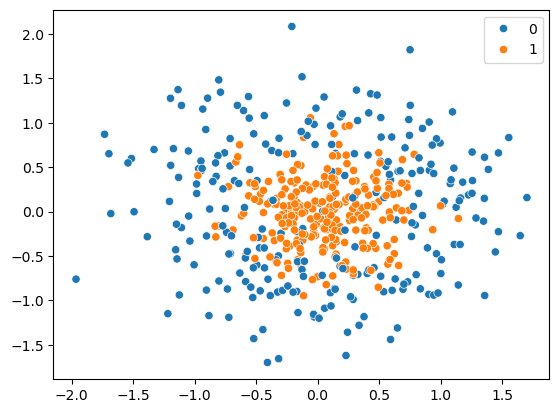

In [8]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y);

# Train test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((400, 2), (100, 2), (400,), (100,))

# Classification

## Decision Tree Classifier

In [9]:
dt = DecisionTreeClassifier()

In [10]:
dt.fit(X_train, y_train)

DecisionTreeClassifier()

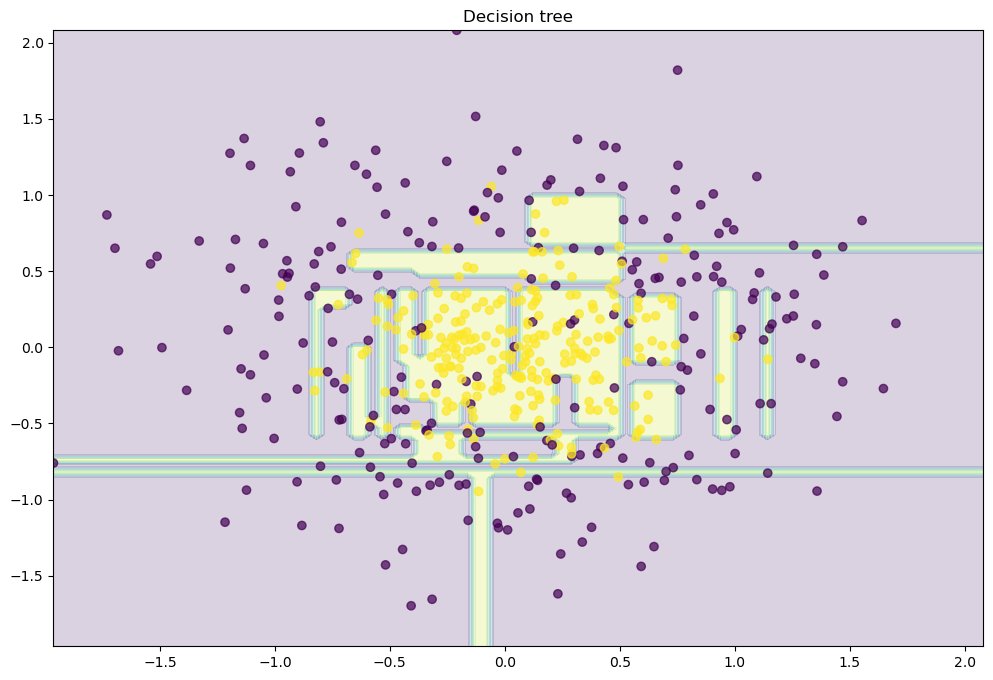

In [16]:
plt.figure(figsize=(12, 8))  
# Create a new figure with a specified size (controls the plot’s dimensions)

x_range = np.linspace(X.min(), X.max(), 100)  
# Generate 100 evenly spaced values between the minimum and maximum values in X
# This defines the range over which we will evaluate the model

xx1, xx2 = np.meshgrid(x_range, x_range)  
# Create a 2D grid of coordinates from the x_range
# xx1 contains x-coordinates, xx2 contains y-coordinates for each grid point

y_hat = dt.predict(np.c_[xx1.ravel(), xx2.ravel()])  
# Flatten the grid into a list of (x, y) points and predict the class for each
# np.c_ stacks the flattened coordinates column-wise to match model input shape

y_hat = y_hat.reshape(xx1.shape)  
# Reshape the 1D prediction array back into the 2D grid shape
# This allows spatial plotting of predicted regions

plt.contourf(xx1, xx2, y_hat, alpha=0.2)  
# Plot filled contours representing the decision regions of the model
# Alpha controls transparency so data points remain visible

plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)  
# Plot the original data points on top of the decision regions
# Points are colored according to their true class labels

plt.title("Decision tree")  
# Add a title to the plot

plt.show()  
# Render and display the final visualization

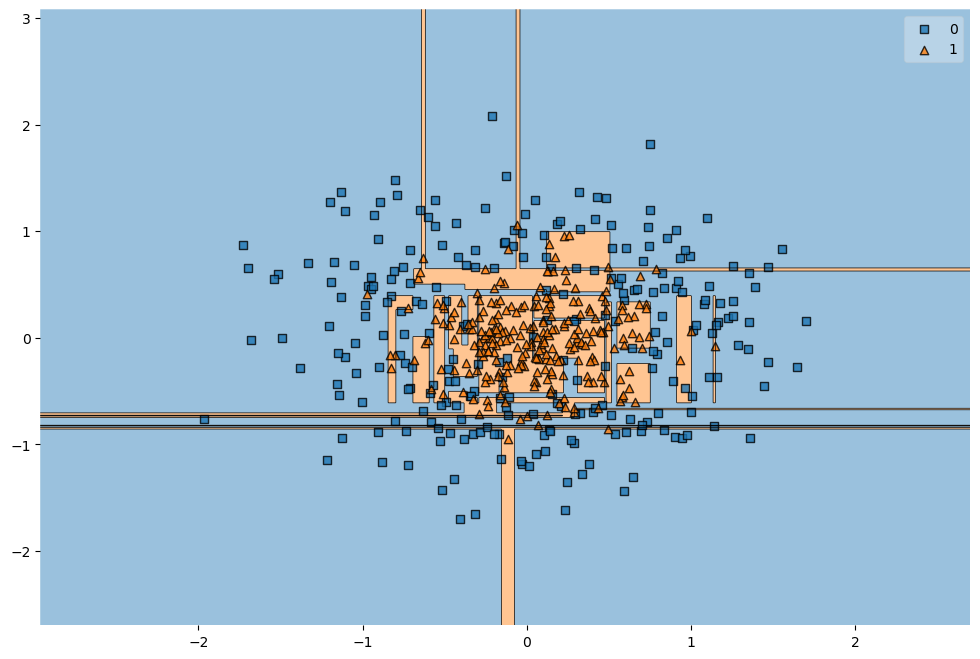

In [15]:
plt.figure(figsize=(12, 8))
plot_decision_regions(X, y, clf=dt)
plt.show();

* Clearly the model is overfitting (see the regions).

## Random Forest Classifier

In [17]:
rfc = RandomForestClassifier(n_estimators=500, random_state=42)

In [18]:
rfc.fit(X_train, y_train)

RandomForestClassifier(n_estimators=500, random_state=42)

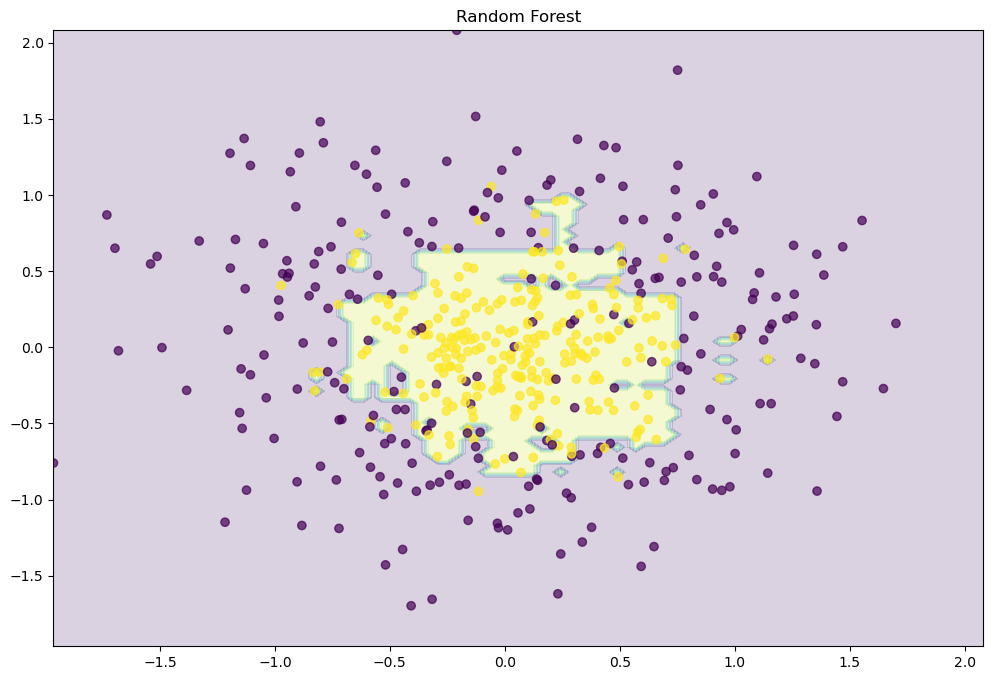

In [20]:
plt.figure(figsize=(12, 8))  
# Create a new figure with a specified size (controls the plot’s dimensions)

x_range = np.linspace(X.min(), X.max(), 100)  
# Generate 100 evenly spaced values between the minimum and maximum values in X
# This defines the range over which we will evaluate the model

xx1, xx2 = np.meshgrid(x_range, x_range)  
# Create a 2D grid of coordinates from the x_range
# xx1 contains x-coordinates, xx2 contains y-coordinates for each grid point

y_hat = rfc.predict(np.c_[xx1.ravel(), xx2.ravel()])  
# Flatten the grid into a list of (x, y) points and predict the class for each
# np.c_ stacks the flattened coordinates column-wise to match model input shape

y_hat = y_hat.reshape(xx1.shape)  
# Reshape the 1D prediction array back into the 2D grid shape
# This allows spatial plotting of predicted regions

plt.contourf(xx1, xx2, y_hat, alpha=0.2)  
# Plot filled contours representing the decision regions of the model
# Alpha controls transparency so data points remain visible

plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)  
# Plot the original data points on top of the decision regions
# Points are colored according to their true class labels

plt.title("Random Forest")  
# Add a title to the plot

plt.show()  
# Render and display the final visualization

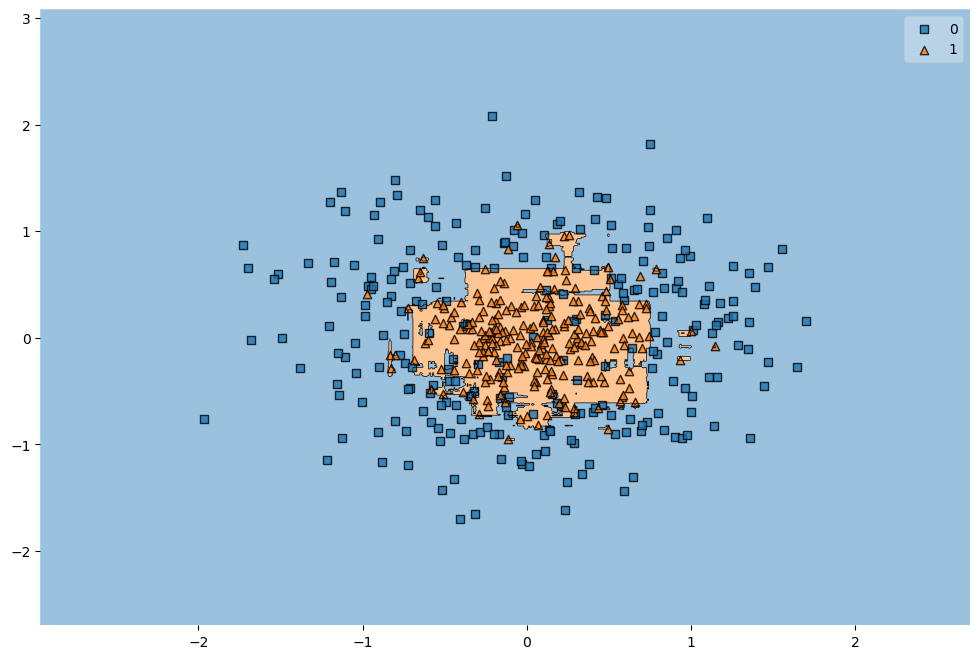

In [21]:
plt.figure(figsize=(12, 8))
plot_decision_regions(X, y, clf=rfc)
plt.show();

* This is way better. Training error can increase a bit but the variance is reduced.

# Regression

In [22]:
n_train = 150        
n_test = 1000       
noise = 0.1

# Generate data
def f(x):
    x = x.ravel()
    return np.exp(-x ** 2) + 1.5 * np.exp(-(x - 2) ** 2)

def generate(n_samples, noise):
    X = np.random.rand(n_samples) * 10 - 5
    X = np.sort(X).ravel()
    y = np.exp(-X ** 2) + 1.5 * np.exp(-(X - 2) ** 2)\
        + np.random.normal(0.0, noise, n_samples)
    X = X.reshape((n_samples, 1))

    return X, y

X_train, y_train = generate(n_samples=n_train, noise=noise)
X_test, y_test = generate(n_samples=n_test, noise=noise)

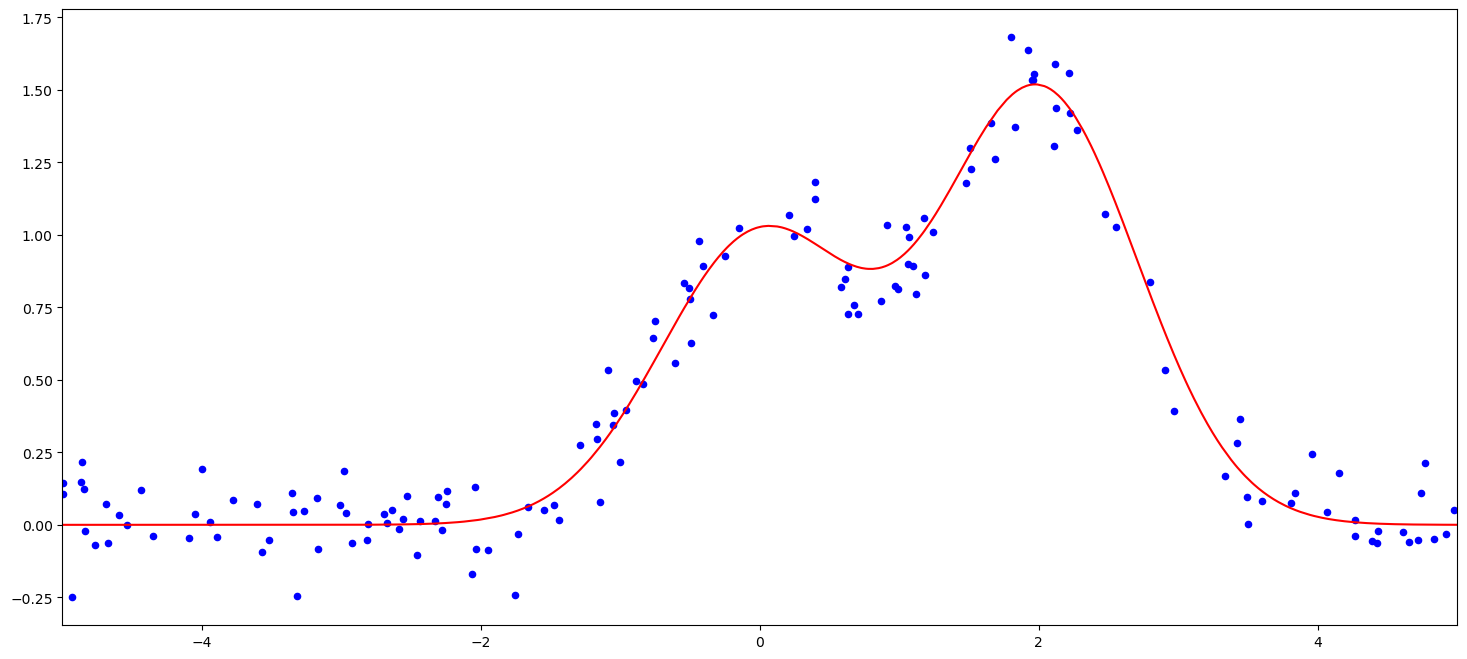

In [24]:
plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.xlim([-5, 5])
plt.show()

## Decision Tree Regressor

In [25]:
dt = DecisionTreeRegressor()

In [26]:
dt.fit(X_train, y_train)

DecisionTreeRegressor()

In [27]:
y_pred = dt.predict(X_test)

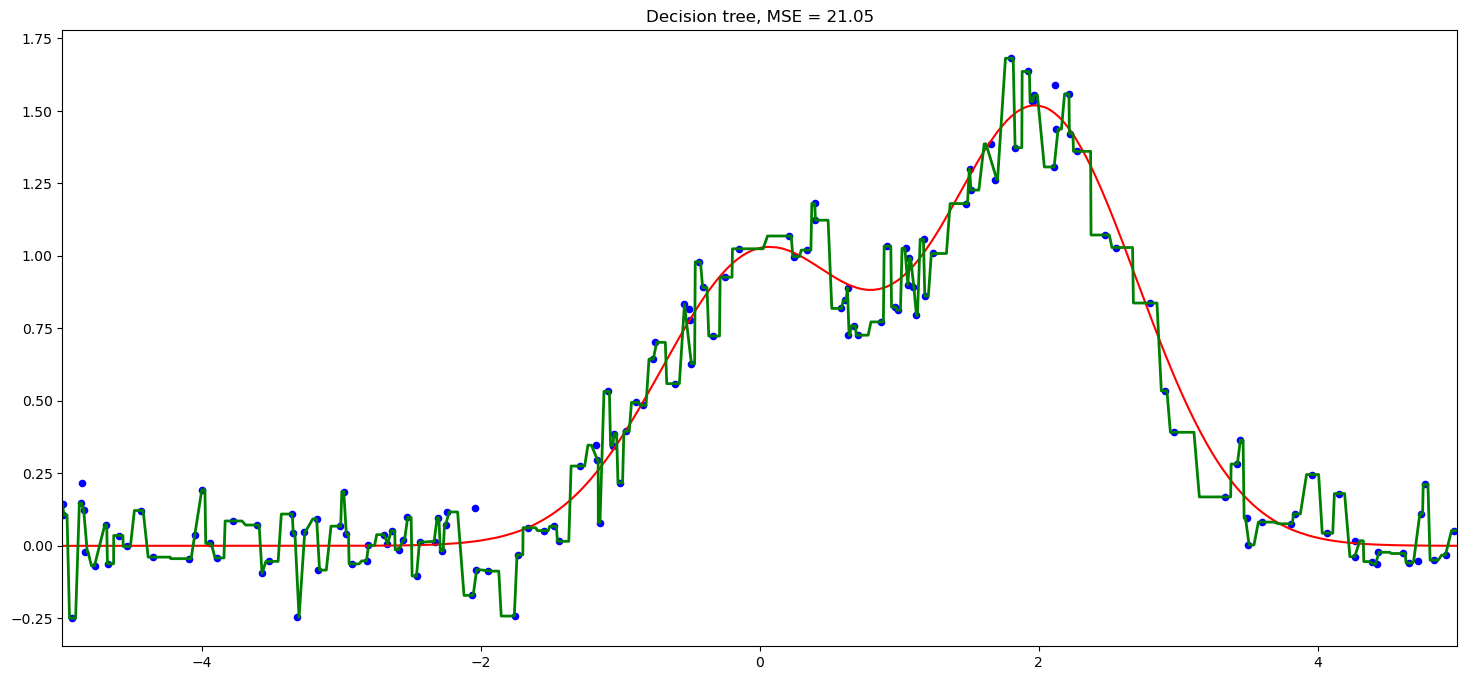

In [30]:
plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, y_pred, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Decision tree, MSE = %.2f" % np.sum((y_test - y_pred) ** 2))
plt.show()

* Model is trying to touch all the training points.

## Random Forest Regressor

In [31]:
rfr = RandomForestRegressor(n_estimators=1000, random_state=42)

In [32]:
rfr.fit(X_train, y_train)

RandomForestRegressor(n_estimators=1000, random_state=42)

In [33]:
y_pred = rfr.predict(X_test)

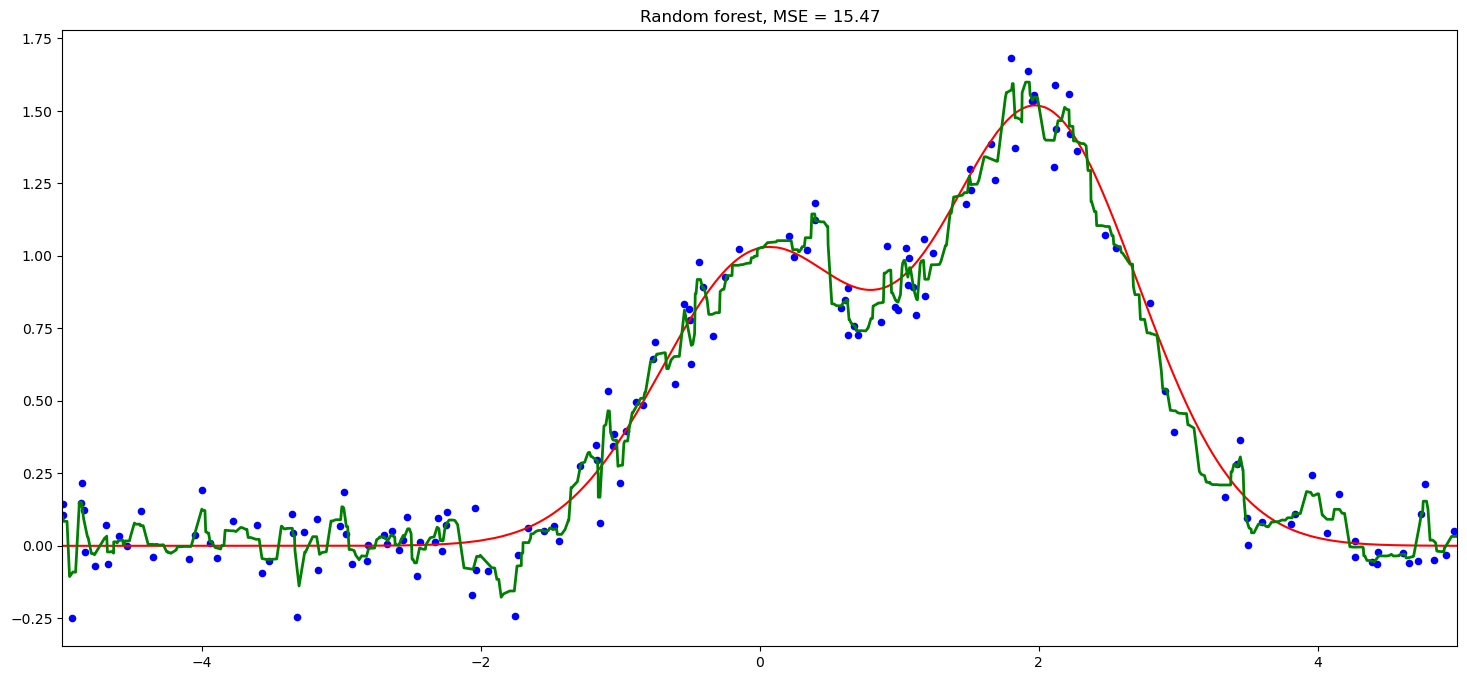

In [35]:
plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, y_pred, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Random forest, MSE = %.2f" % np.sum((y_test - y_pred) ** 2));
plt.show()

* MSE is reduced. 